In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import os
import tempfile
try:
    from torchvision import datasets, transforms
except Exception:
    datasets = None
    transforms = None

try:
    from tqdm.auto import tqdm
except Exception:
    class SimpleProgress:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable

        def __iter__(self):
            return iter(self.iterable)

        def set_postfix(self, values):
            pass

    def tqdm(iterable, **kwargs):
        return SimpleProgress(iterable, **kwargs)

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))

import matplotlib.pyplot as plt

/Users/szy/miniconda3/envs/HiMCM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 手写数字识别模型

class DigitRecognizer(nn.Module):
    def __init__(self):
        super(DigitRecognizer, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [3]:
# 导入数据集
def load_digit_data(batch_size=64, download_mnist=False):
    """优先读取本地 MNIST；如果没有本地文件，退回 sklearn 内置手写数字数据集。"""
    if datasets is not None:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        try:
            train_dataset = datasets.MNIST(
                root="./data",
                train=True,
                download=download_mnist,
                transform=transform
            )
            test_dataset = datasets.MNIST(
                root="./data",
                train=False,
                download=download_mnist,
                transform=transform
            )
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
            print("已加载 MNIST 数据集")
            return train_loader, test_loader
        except Exception as error:
            print(f"MNIST 加载失败，改用 sklearn digits 数据集：{error}")

    digits = load_digits()
    images = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
    images = nn.functional.interpolate(images, size=(28, 28), mode="bilinear")
    labels = torch.tensor(digits.target, dtype=torch.long)
    x_train, x_test, y_train, y_test = train_test_split(
        images,
        labels,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )
    train_dataset = TensorDataset(x_train, y_train)
    test_dataset = TensorDataset(x_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    print("已加载 sklearn digits 数据集")
    return train_loader, test_loader


In [4]:
# 训练集与测试集的划分
def split_train_validation(train_loader, validation_ratio=0.1, batch_size=64):
    train_dataset = train_loader.dataset
    validation_size = int(len(train_dataset) * validation_ratio)
    train_size = len(train_dataset) - validation_size
    train_subset, validation_subset = random_split(
        train_dataset,
        [train_size, validation_size],
        generator=torch.Generator().manual_seed(42)
    )
    new_train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_subset, batch_size=batch_size, shuffle=False)
    return new_train_loader, validation_loader



In [5]:
# 模型架构的设计与加载
def build_model(device):
    model = DigitRecognizer().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    return model, criterion, optimizer



In [6]:
# train fit， tqdm 进度可视化
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        predictions = outputs.argmax(dim=1)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_samples += batch_size

        progress_bar.set_postfix({
            "loss": total_loss / total_samples,
            "acc": total_correct / total_samples
        })

    return total_loss / total_samples, total_correct / total_samples


In [7]:

def fit(model, train_loader, validation_loader, criterion, optimizer, device, epochs=2):
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            epoch
        )
        val_loss, val_acc, _, _ = evaluate(model, validation_loader, criterion, device)
        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )


# predict 展示单次预测的输入输出和结果
def predict_one(model, test_loader, device, save_path="notebooks/prediction_example.png"):
    model.eval()
    images, labels = next(iter(test_loader))
    image = images[0:1].to(device)
    true_label = labels[0].item()

    with torch.no_grad():
        logits = model(image)
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = probabilities.argmax(dim=1).item()
        confidence = probabilities.max().item()

    print("单次预测输入 shape:", tuple(image.shape))
    print("模型原始输出 logits:", logits.cpu().numpy().round(3))
    print(f"真实标签: {true_label}, 预测标签: {predicted_label}, 置信度: {confidence:.2%}")

    plt.figure(figsize=(3, 3))
    plt.imshow(images[0].squeeze().numpy(), cmap="gray")
    plt.title(f"true={true_label}, pred={predicted_label}")
    plt.axis("off")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show(block=False)
    plt.close()
    print(f"预测图片已保存: {save_path}")


# eval 在测试集上批量评估模型指标
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            predictions = outputs.argmax(dim=1)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    accuracy = accuracy_score(all_labels, all_predictions)
    return total_loss / total_samples, accuracy, all_labels, all_predictions


In [8]:
torch.manual_seed(42)
batch_size = 64
epochs = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

使用设备: cpu


In [9]:
train_loader, test_loader = load_digit_data(batch_size=batch_size, download_mnist=False)
train_loader, validation_loader = split_train_validation(
    train_loader,
    validation_ratio=0.1,
    batch_size=batch_size
)

已加载 MNIST 数据集


In [10]:
model, criterion, optimizer = build_model(device)
print(model)

DigitRecognizer(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
)


In [11]:
fit(model, train_loader, validation_loader, criterion, optimizer, device, epochs=epochs)

Epoch 1: 100%|██████████| 844/844 [00:53<00:00, 15.66it/s, loss=0.138, acc=0.957]


Epoch 1: train_loss=0.1379, train_acc=0.9574, val_loss=0.0627, val_acc=0.9823


Epoch 2: 100%|██████████| 844/844 [00:48<00:00, 17.39it/s, loss=0.0422, acc=0.987]


Epoch 2: train_loss=0.0422, train_acc=0.9869, val_loss=0.0556, val_acc=0.9848


单次预测输入 shape: (1, 1, 28, 28)
模型原始输出 logits: [[ -1.746  -5.696   1.065   0.764  -7.491  -5.022 -15.803  14.04   -2.281
    0.478]]
真实标签: 7, 预测标签: 7, 置信度: 100.00%


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/prediction_example.png'

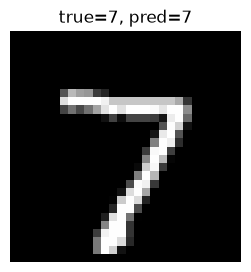

In [12]:
predict_one(model, test_loader, device)

In [ ]:
test_loss, test_accuracy, true_labels, predicted_labels = evaluate(
    model,
    test_loader,
    criterion,
    device
)
print(f"测试集 loss={test_loss:.4f}, accuracy={test_accuracy:.4f}")
print(classification_report(true_labels, predicted_labels))